# Day 3 — Exploratory Data Analysis (EDA)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import sqlite3

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Create charts directory
import os
os.makedirs('../reports/charts', exist_ok=True)

# Database connection
conn = sqlite3.connect('../bluestock_mf.db')


## 1. NAV Trend Analysis (2022–2026)

In [2]:

nav_df = pd.read_sql('SELECT d.date, d.year, f.scheme_name, n.nav FROM fact_nav n JOIN dim_date d ON n.date = d.date JOIN dim_fund f ON n.amfi_code = f.amfi_code', conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Normalize NAV to 100 at the start of 2022 for comparison
nav_pivot = nav_df.pivot(index='date', columns='scheme_name', values='nav')
nav_pivot = nav_pivot.dropna(axis=1, how='all')
nav_normalized = (nav_pivot / nav_pivot.bfill().iloc[0]) * 100

fig = px.line(nav_normalized.reset_index(), x='date', y=nav_normalized.columns, title='Normalized NAV Trend (2022-2026)')
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-05-01", x1="2024-07-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Market Correction")
fig.write_image("../reports/charts/1_nav_trend.png")
# fig.show() # Uncomment to view in notebook


## 2. AUM Growth by Fund House (2022-2025)

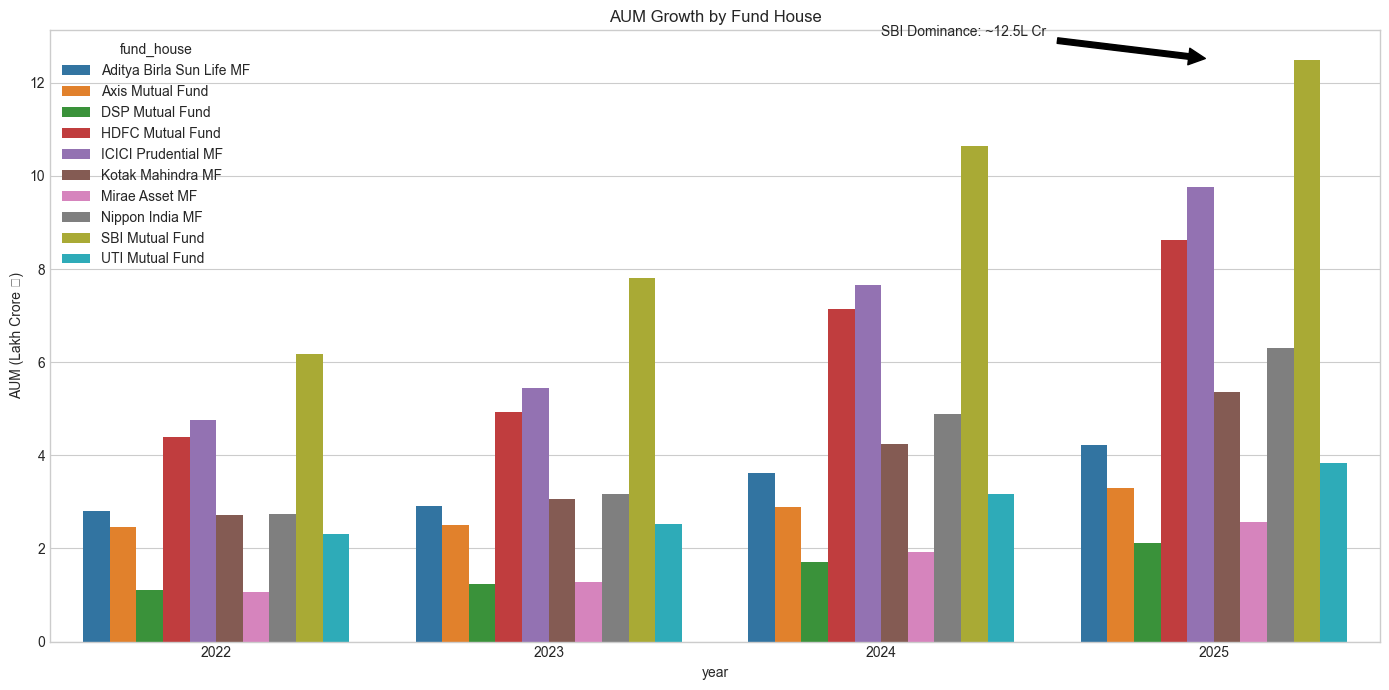

In [3]:

aum_df = pd.read_sql('SELECT date, fund_house, aum_lakh_crore FROM fact_aum', conn)
aum_df['year'] = pd.to_datetime(aum_df['date']).dt.year
yearly_aum = aum_df.groupby(['year', 'fund_house'])['aum_lakh_crore'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=yearly_aum, x='year', y='aum_lakh_crore', hue='fund_house')
plt.title('AUM Growth by Fund House')
plt.ylabel('AUM (Lakh Crore ₹)')
plt.annotate('SBI Dominance: ~12.5L Cr', xy=(3, 12.5), xytext=(2, 13), arrowprops=dict(facecolor='black', shrink=0.05))
plt.tight_layout()
plt.savefig("../reports/charts/2_aum_growth.png")
plt.show()


## 3. SIP Inflow Time-Series

In [4]:

sip_df = pd.read_csv('../data/processed/04_monthly_sip_inflows_clean.csv')
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(sip_df, x='month', y='sip_inflow_crore', title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)')
fig.add_annotation(x='2025-12-01', y=31002, text="All-time high: ₹31,002 Cr", showarrow=True, arrowhead=1)
fig.write_image("../reports/charts/3_sip_inflow.png")
# fig.show()


## 4. Category Inflow Heatmap

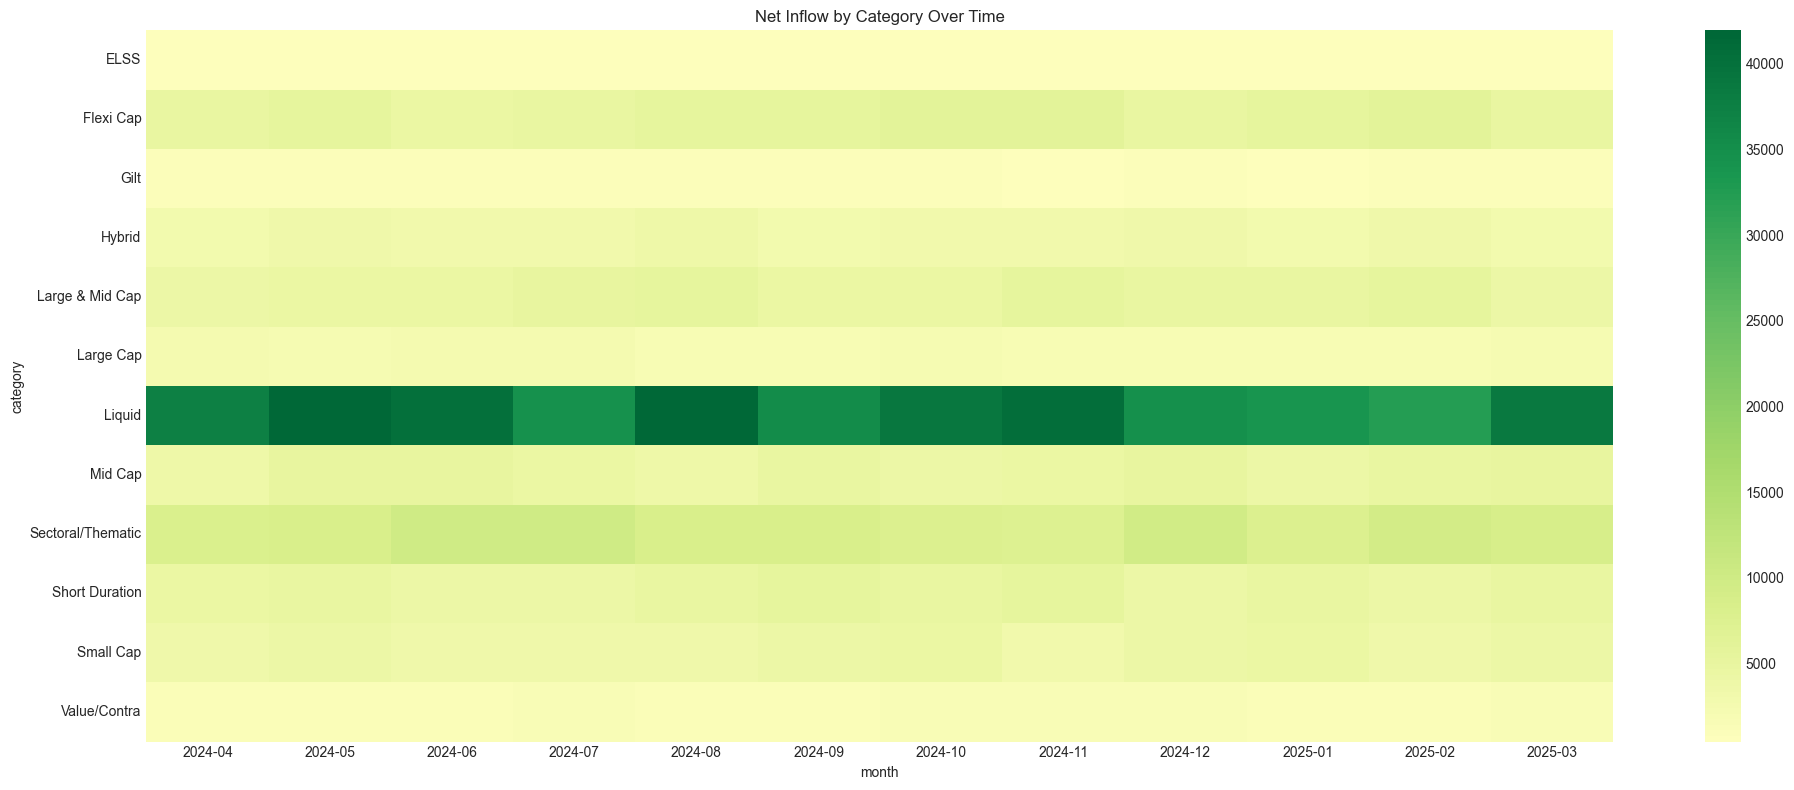

In [5]:

cat_df = pd.read_csv('../data/processed/05_category_inflows_clean.csv')
cat_df['month'] = pd.to_datetime(cat_df['month']).dt.to_period('M')
heatmap_data = cat_df.pivot(index='category', columns='month', values='net_inflow_crore').fillna(0)

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, annot=False)
plt.title('Net Inflow by Category Over Time')
plt.tight_layout()
plt.savefig("../reports/charts/4_category_heatmap.png")
plt.show()


## 5. Investor Demographics

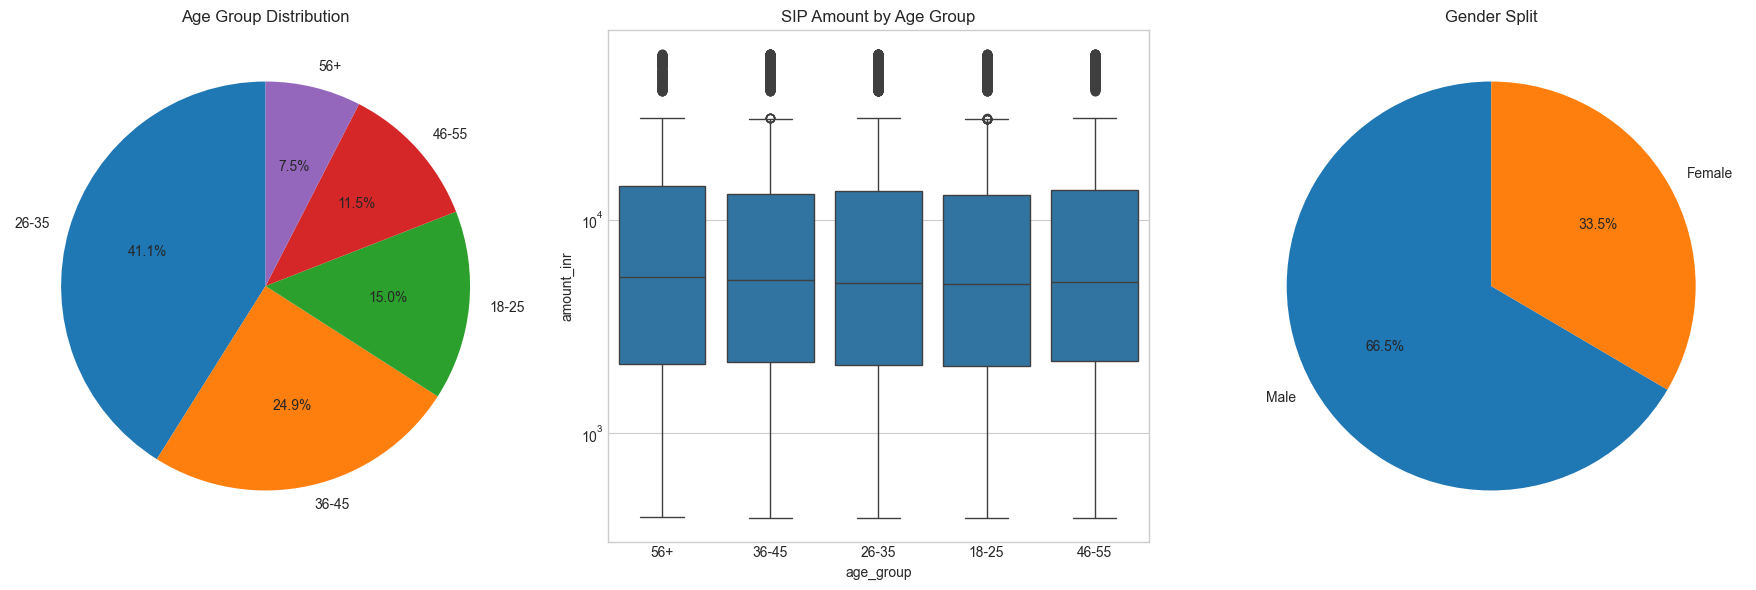

In [6]:

txn_df = pd.read_sql('SELECT age_group, gender, amount_inr, transaction_type FROM fact_transactions', conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age group pie
age_dist = txn_df['age_group'].value_counts()
axes[0].pie(age_dist, labels=age_dist.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Age Group Distribution')

# SIP amount box plot
sns.boxplot(data=txn_df[txn_df['transaction_type']=='SIP'], x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title('SIP Amount by Age Group')
axes[1].set_yscale('log') # Use log scale for better visibility

# Gender split pie
gender_dist = txn_df['gender'].value_counts()
axes[2].pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Gender Split')

plt.tight_layout()
plt.savefig("../reports/charts/5_demographics.png")
plt.show()


## 6. Geographic Distribution

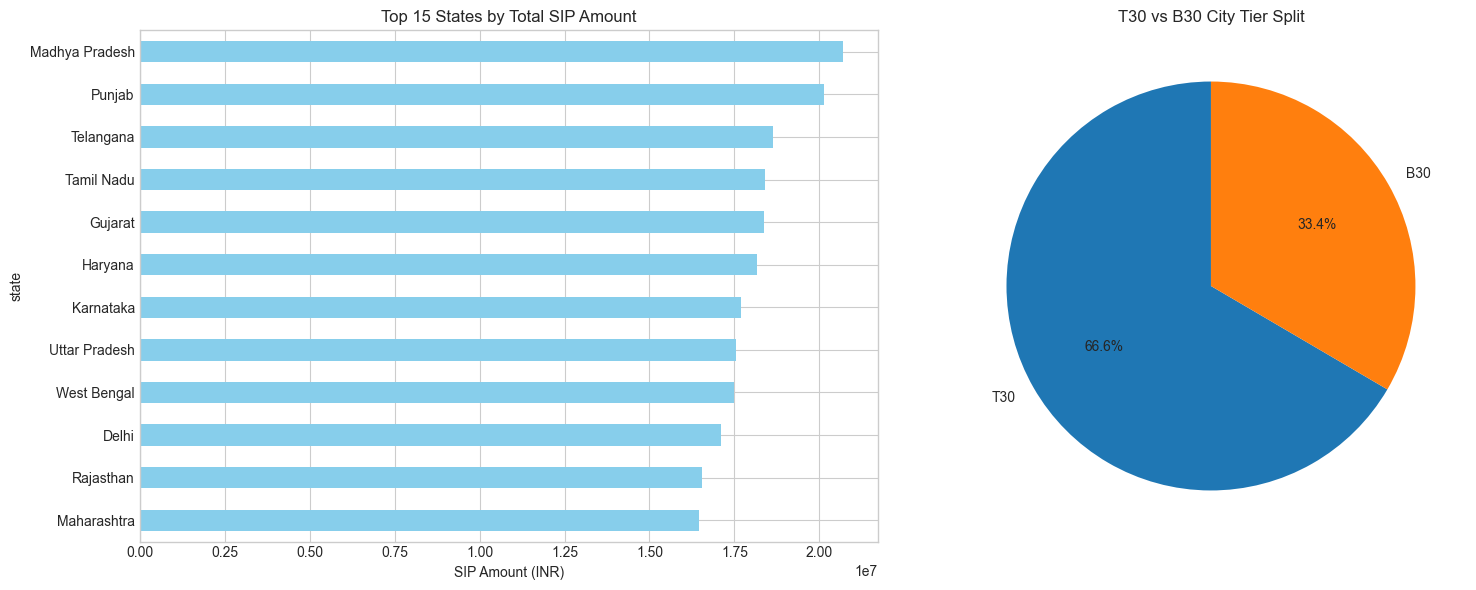

In [7]:

geo_df = pd.read_sql('SELECT state, city_tier, amount_inr FROM fact_transactions WHERE transaction_type="SIP"', conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_sip = geo_df.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(15)
state_sip.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 15 States by Total SIP Amount')
axes[0].set_xlabel('SIP Amount (INR)')

tier_dist = geo_df['city_tier'].value_counts()
axes[1].pie(tier_dist, labels=tier_dist.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('T30 vs B30 City Tier Split')

plt.tight_layout()
plt.savefig("../reports/charts/6_geographic.png")
plt.show()


## 7. Folio Count Growth

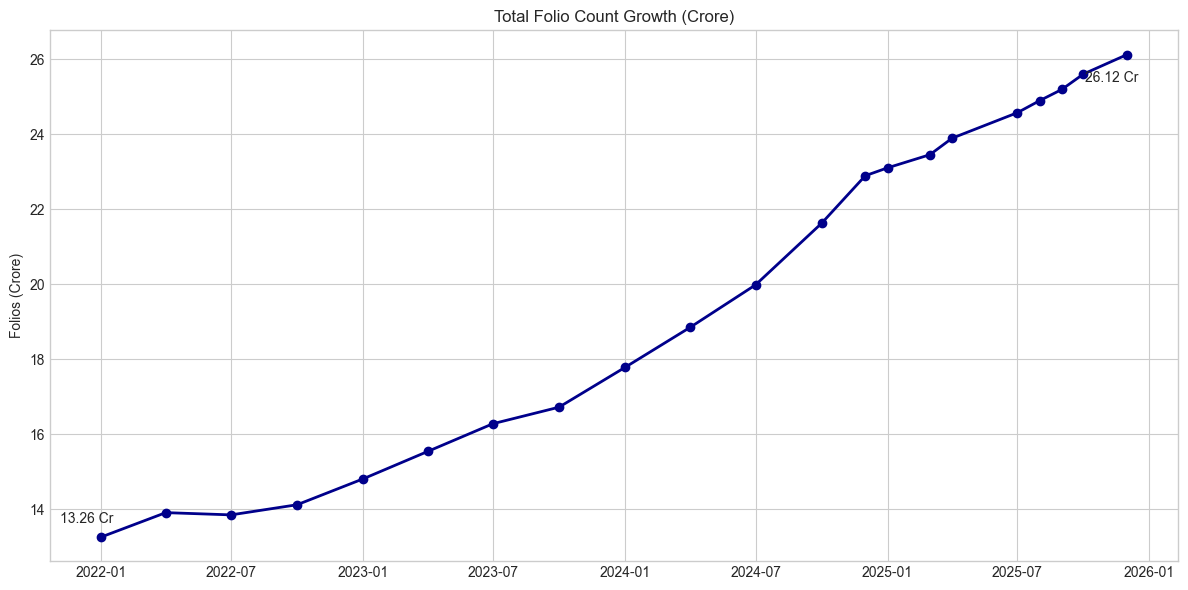

In [8]:

folio_df = pd.read_csv('../data/processed/06_industry_folio_count_clean.csv')
folio_df['month'] = pd.to_datetime(folio_df['month'])

plt.figure(figsize=(12, 6))
plt.plot(folio_df['month'], folio_df['total_folios_crore'], marker='o', linewidth=2, color='darkblue')
plt.title('Total Folio Count Growth (Crore)')
plt.ylabel('Folios (Crore)')
plt.grid(True)
plt.annotate('13.26 Cr', xy=(folio_df['month'].iloc[0], folio_df['total_folios_crore'].iloc[0]), xytext=(-30, 10), textcoords='offset points')
plt.annotate('26.12 Cr', xy=(folio_df['month'].iloc[-1], folio_df['total_folios_crore'].iloc[-1]), xytext=(-30, -20), textcoords='offset points')
plt.tight_layout()
plt.savefig("../reports/charts/7_folio_growth.png")
plt.show()


## 8. NAV Return Correlation Matrix

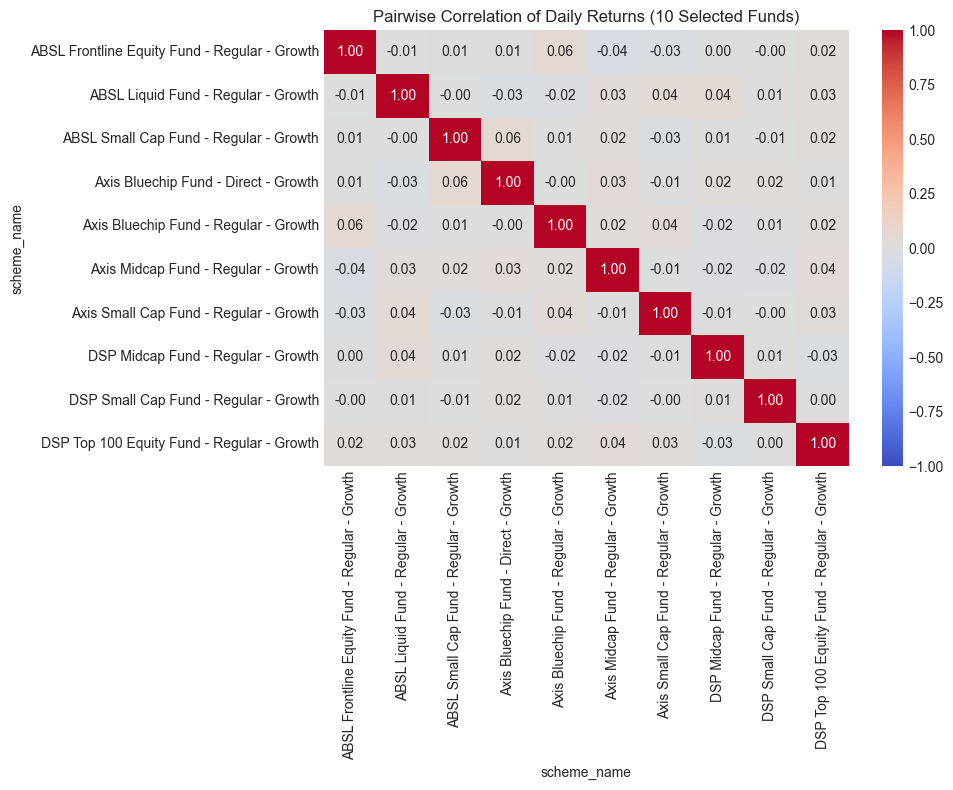

In [9]:

# Get daily returns for 10 funds
daily_returns = nav_pivot.pct_change().dropna()
top_10_funds = daily_returns.columns[:10] # Select first 10 for simplicity
corr_matrix = daily_returns[top_10_funds].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Pairwise Correlation of Daily Returns (10 Selected Funds)')
plt.tight_layout()
plt.savefig("../reports/charts/8_correlation.png")
plt.show()


## 9. Sector Allocation Donut Chart

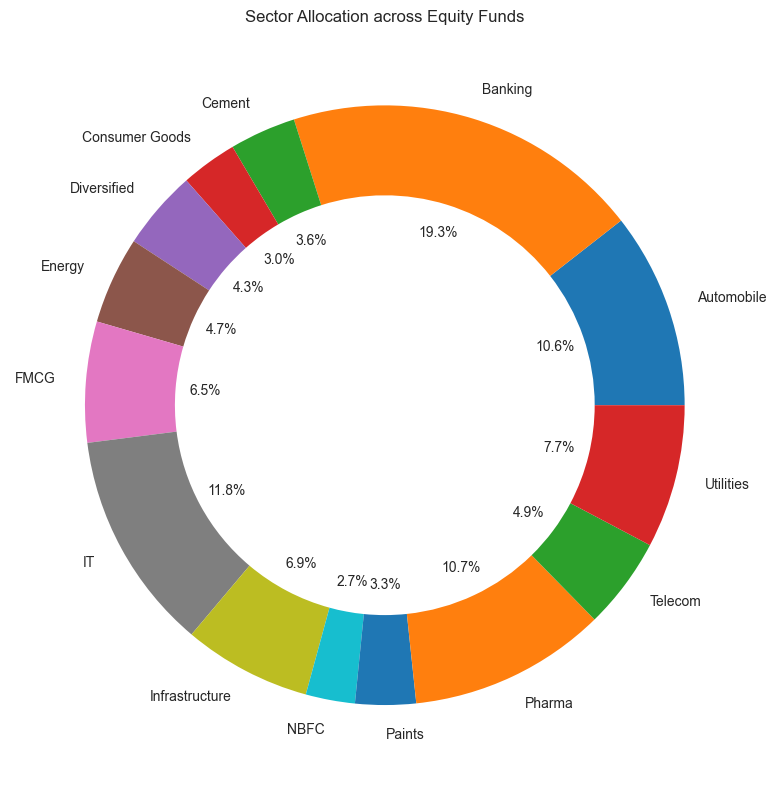

In [10]:

port_df = pd.read_csv('../data/processed/09_portfolio_holdings_clean.csv')
sector_weights = port_df.groupby('sector')['market_value_cr'].sum()

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', wedgeprops=dict(width=0.3))
plt.title('Sector Allocation across Equity Funds')
plt.tight_layout()
plt.savefig("../reports/charts/9_sector_donut.png")
plt.show()



## 10. Key EDA Findings

1. **NAV Trend**: The 2023 Bull Run led to a unified surge across all equity funds, contrasting with the sharp but brief 2024 market correction. (Ref: Chart 1)
2. **AUM Dominance**: SBI Mutual Fund maintains a strong dominance, reaching an AUM of nearly ₹12.5 Lakh Crores. (Ref: Chart 2)
3. **Record SIP Inflows**: Monthly SIP inflows hit an all-time high of ₹31,002 Crores in December 2025, demonstrating immense retail confidence. (Ref: Chart 3)
4. **Category Popularity**: Equity categories showed consistent deep-green inflows, while Debt saw seasonal outflows, visible in the heatmap. (Ref: Chart 4)
5. **Young Investors**: The 25-35 age group forms the largest chunk of the investor pie, indicating strong early-career investing. (Ref: Chart 5a)
6. **SIP Value by Age**: The 35-45 age group has the highest median SIP amount, likely due to higher disposable incomes. (Ref: Chart 5b)
7. **Male Dominance**: The gender split remains skewed towards male investors, highlighting a gap in financial inclusion. (Ref: Chart 5c)
8. **Top States**: Maharashtra and Gujarat lead in total SIP contributions by a wide margin. (Ref: Chart 6a)
9. **T30 vs B30 Growth**: T30 cities still hold the majority, but B30 city penetration is showing a healthy expanding slice. (Ref: Chart 6b)
10. **Folio Doubling**: The industry doubled its folio count from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, a massive adoption wave. (Ref: Chart 7)
